In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Windows 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

기울기 (a) : 489.0349
절편 (a) : 10168.7882
MSE : 707061.1951
R2 score : 0.9899


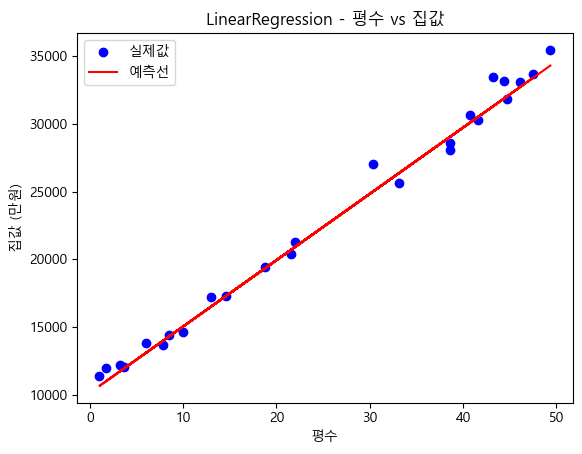

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
X = np.random.rand(100,1) * 50
y = 500 * X.squeeze() + 10000 + np.random.randn(100) * 1000

x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(f"기울기 (a) : {model.coef_[0]:.4f}")
print(f"절편 (a) : {model.intercept_:.4f}")
print(f"MSE : {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2 score : {r2_score(y_test, y_pred):.4f}")

plt.scatter(x_test, y_test, color='blue', label='실제값')
plt.plot(x_test, y_pred, color='red', label='예측선')
plt.xlabel('평수')
plt.ylabel('집값 (만원)')
plt.title("LinearRegression - 평수 vs 집값")
plt.legend()
plt.show()

기울기 (a) : 2.7259
절편 (b) : 508.4394
MSE : 1767.6530
R2_score : 0.8311


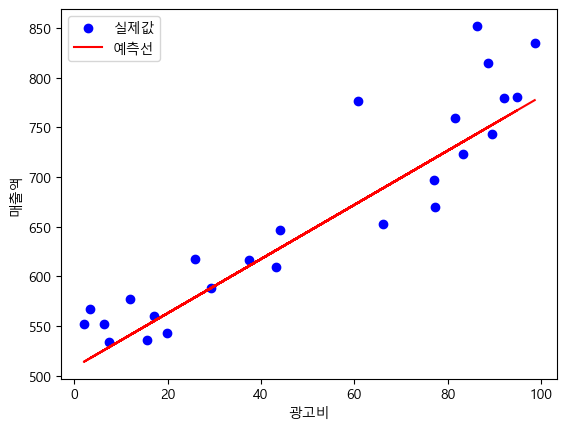

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
X = np.random.rand(100,1) * 100
y = 3 * X.squeeze() + 500 + np.random.randn(100) * 50

x_train,x_test,y_train,y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"기울기 (a) : {model.coef_[0]:.4f}")
print(f"절편 (b) : {model.intercept_:.4f}")
print(f"MSE : {mse:.4f}")
print(f"R2_score : {r2:.4f}")

plt.scatter(x_test, y_test, color='b', label='실제값')
plt.plot(x_test, y_pred, color='r', label='예측선')
plt.xlabel('광고비')
plt.ylabel('매출액')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.datasets import load_breast_cancer

# 유방암 데이터 로드 (양성/악성 분류)
# 0: 악성, 1: 양성
data = load_breast_cancer()
X = data.data
y = data.target

x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

model = LogisticRegression(max_iter=10000) # max_iter : 학습 반복 횟수
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test) # predict_proba : 분류 모델에서만 사용(예측 확률)

print("에측 확률 (앞 5개)")
print(y_prob[:5])
print(y_pred[:5])
print()

# 성능 평가
print(classification_report(y_test, y_pred, target_names=['악성', '양성']))

에측 확률 (앞 5개)
[[0.01852011 0.98147989]
 [0.99814932 0.00185068]
 [0.17696445 0.82303555]
 [0.23346312 0.76653688]
 [0.19904109 0.80095891]]
[1 0 1 1 1]

              precision    recall  f1-score   support

          악성       0.98      0.91      0.94        53
          양성       0.95      0.99      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.datasets import load_wine

data = load_wine()

X = data.data
y = data.target

x_train,x_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)

print(y_prob[:5])
print(y_pred[:5])

print(classification_report(y_test,y_pred))


[[9.99970681e-01 3.81382208e-06 2.55047364e-05]
 [3.13600115e-02 3.05392848e-01 6.63247140e-01]
 [9.53844896e-01 4.53373665e-02 8.17737670e-04]
 [3.76439427e-01 6.16656412e-01 6.90416116e-03]
 [1.64419217e-02 9.80129655e-01 3.42842364e-03]]
[0 2 0 1 1]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

feature 중요도
sepal length (cm) : 0.0063
sepal width (cm) : 0.0169
petal length (cm) : 0.5656
petal width (cm) : 0.4112


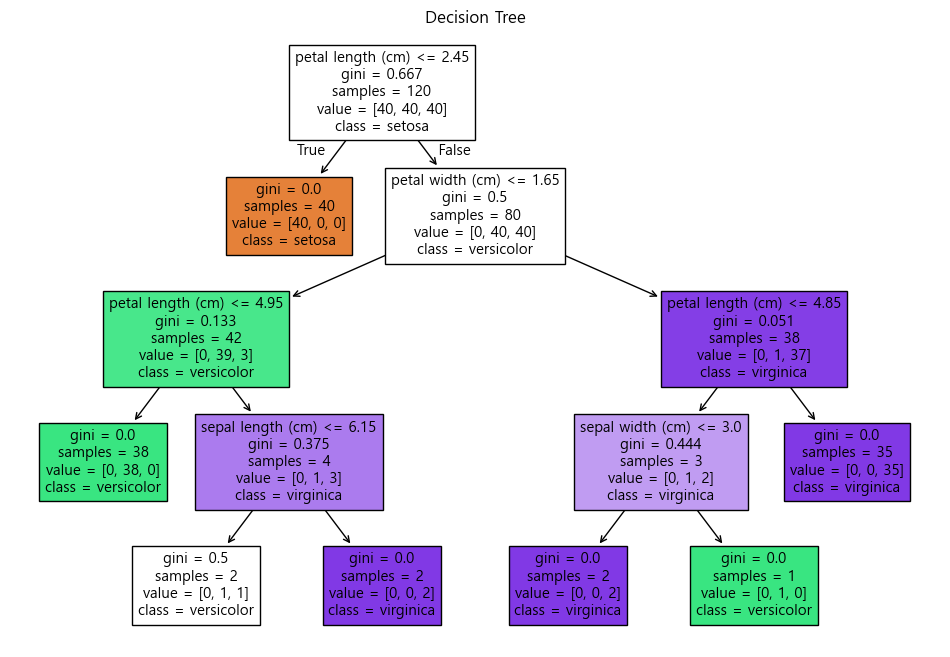

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target

x_train,x_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify = y)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred, target_names = data.target_names))

print("feature 중요도")
for name, importance in zip(data.feature_names, model.feature_importances_):
    print(f"{name} : {importance:.4f}")

plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=data.feature_names,
    class_names = data.target_names,
    filled=True # 클래스별 색상표시
)
plt.title('Decision Tree')
plt.show()

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.datasets import load_breast_cancer
data=load_breast_cancer()

X = data.data
y = data.target

x_train,x_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state=42, stratify = y)

model = DecisionTreeClassifier(max_depth = 5, random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)

print( classification_report(y_test, y_pred, target_names = data.target_names) )

importances = [[name, importance] for name, importance in zip(data.feature_names, model.feature_importances_)]

sorted_importances = sorted(importances, key=lambda x: x[1], reverse=True)
print( pd.DataFrame(sorted_importances[:5]) )



              precision    recall  f1-score   support

   malignant       0.87      0.93      0.90        42
      benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114

                      0         1
0          worst radius  0.714332
1  worst concave points  0.118831
2         texture error  0.053907
3         worst texture  0.031473
4       worst concavity  0.016712


In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline

data = load_iris()
X = data.data
y = data.target

x_train,x_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

k_dict = {}
for k in [1, 3, 5, 7, 9]:

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('KNeighbors', KNeighborsClassifier(n_neighbors=k))
    ])
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)
    accuracy = (y_pred == y_test).mean()
    k_dict[k] = accuracy
    print(f"K = {k} 정확도 : {accuracy:.4f}")

top = sorted(k_dict.items(), key = lambda x : x[1], reverse=True)

top_list = [list(x) for x in top]
top_list
k = int( top_list[0][0] )

model = KNeighborsClassifier(n_neighbors=k)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)

print(classification_report(y_test, y_pred))





K = 1 정확도 : 0.9667
K = 3 정확도 : 0.9333
K = 5 정확도 : 0.9333
K = 7 정확도 : 0.9667
K = 9 정확도 : 0.9667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.91      1.00      0.95        10
           2       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [89]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_wine

data = load_wine()

X = data.data
y = data.target

x_train,x_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

k_dict = {}
for k in [1, 3, 5, 7, 9]:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('KNeighbors', KNeighborsClassifier(n_neighbors=k))
    ])
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)
    accuracy = (y_test == y_pred).mean()
    k_dict[k] = accuracy

top = sorted(k_dict.items(), key = lambda x : x[1], reverse=True)

top_list = [list(x) for x in top]
k = int( top_list[0][0] )

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('KNeighbors', KNeighborsClassifier(n_neighbors = k))
])
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)

print( classification_report(y_test, y_pred) )



              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

                 feature  importance
23            worst area    0.138294
27  worst concave points    0.132993
20          worst radius    0.100805
7    mean concave points    0.098489
22       worst perimeter    0.072224


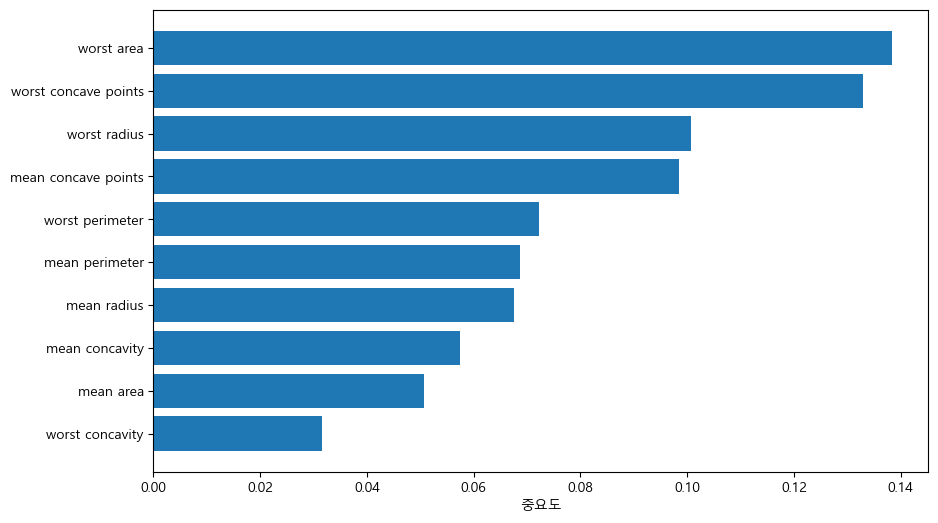

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target

x_train,x_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify = y)

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(x_train,y_train)

y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)

print(classification_report(y_test, y_pred, target_names=data.target_names))

importances = pd.DataFrame({
    'feature' : data.feature_names,
    'importance' : model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(5))

plt.figure(figsize=(10,6))
plt.barh(importances['feature'][:10], importances['importance'][:10])
plt.xlabel('중요도')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.datasets import load_wine
data = load_wine()

X = data.data
y = data.target

x_train,x_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify = y)

importance = {}
for n in [10, 50, 100, 200]:
    model = RandomForestClassifier(n_estimators = n)
    model.fit(x_train, y_train)

    model.predict(x_test)
    model.predict_proba(x_test)

    model.feature_importances_

# model = RandomForestClassifier(n_estimators = best)
# model.fit(x_train, y_train)
# y_pred = model.predict(x_test)

# print(classification_report(y_test, y_pred, target_names = data.target_names))



array([0.12294981, 0.03636272, 0.01611283, 0.02246879, 0.03963712,
       0.05192777, 0.14365055, 0.00908864, 0.02784335, 0.17344048,
       0.08489248, 0.11243772, 0.15918776])